In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [156]:
df = pd.read_csv('C:\\Users\\Hitarth Khatiwala\\HEMS\\hems_backend\\EE_EC_AIML(NEW).csv')

In [157]:
df.head()

,,BUILDING,ROOM,2x2 LIGHT,WATT,LED-TB,WATT.1,SENSOR LIGHT,WATT.2,ROUND TB,...,RF,WATT.15,MICROWAVE,WATT.16,INDUCTION,WATT.17,TV,WATT.18,Unnamed: 45,Others
0,NaN,NaN,101,0.0,36.0,2.0,20.0,0.0,20.0,2,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN
1,NaN,NaN,102,5.0,36.0,3.0,20.0,0.0,20.0,0,...,1.0,NaN,1.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN
2,NaN,NaN,106,10.0,36.0,0.0,20.0,0.0,20.0,0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN
3,NaN,NaN,107,0.0,36.0,0.0,20.0,0.0,20.0,0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN
4,NaN,NaN,108,9.0,36.0,4.0,20.0,0.0,20.0,0,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN


In [158]:
df.columns

Index([' ', 'BUILDING', 'ROOM ', '2x2 LIGHT ', 'WATT', 'LED-TB', 'WATT.1',
       'SENSOR LIGHT', 'WATT.2', 'ROUND TB', 'WATT.3', 'FLOODE', 'WATT.4',
       'CIRCLE LIGHT', 'WATT.5', 'C FAN', 'WATT.6', 'WALL FAN', 'WATT.7',
       'TABLE FAN', 'WATT.8', 'EXHAUST FAN', 'WATT.9', 'COOLER', 'WATT.10',
       'AC COMPANY', 'AC', 'STAR RATING', 'WATT.11', 'AC TON', 'ISEER',
       'PROJECTOR', 'WATT.12', 'PC', 'WATT.13', 'PRINTER', 'WATT.14', 'RF',
       'WATT.15', 'MICROWAVE', 'WATT.16', 'INDUCTION', 'WATT.17', 'TV',
       'WATT.18', 'Unnamed: 45', 'Others '],
      dtype='object')

In [159]:
df['AC COMPANY'].value_counts()

AC COMPANY
0                     39
HITACHI               12
AKBHASHI               8
Mitsubishi             5
TOSHIBA                4
Mitsubishi             4
TOSHIBHA               4
Hitachi                2
AKABISHI               2
HITACHI                2
CARRIER                2
Mitsubishi,carrier     1
LLOYD                  1
carrier                1
Toshiba                1
Carrier,LLOYD          1
carrier                1
casete                 1
Name: count, dtype: int64

In [160]:
brand_mapping = {
    # HITACHI
    'HITACHI': 'HITACHI',
    'Hitachi': 'HITACHI',
    'HITACH': 'HITACHI',

    # MITSUBISHI
    'Mitsubishi': 'MITSUBISHI',
    'Mitsubishi ': 'MITSUBISHI',
    'AKBHASHI': 'MITSUBISHI',   # assuming typo
    'AKABISHI': 'MITSUBISHI',   # assuming typo

    # TOSHIBA
    'TOSHIBA': 'TOSHIBA',
    'Toshiba': 'TOSHIBA',
    'TOSHIBHA': 'TOSHIBA',

    # CARRIER
    'CARRIER': 'CARRIER',
    'Carrier': 'CARRIER',
    'carrier': 'CARRIER',

    # LLOYD
    'LLOYD': 'LLOYD',

    # Unknown
    0: 'UNKNOWN',
    'casete': 'UNKNOWN'
}


In [161]:
def clean_ac_company(value):
    if pd.isna(value):
        return 'UNKNOWN'
    
    value = str(value).strip()
    
    
    if ',' in value:
        value = value.split(',')[0] 
    
    value = value.strip()
    
    
    if value in brand_mapping:
        return brand_mapping[value]
    
    
    value_upper = value.upper()
    
    if value_upper in brand_mapping:
        return brand_mapping[value_upper]
    
    return 'UNKNOWN'


In [162]:
df['AC COMPANY CLEANED'] = df['AC COMPANY'].apply(clean_ac_company)

df['AC COMPANY CLEANED'].value_counts()


AC COMPANY CLEANED
UNKNOWN       84
MITSUBISHI    20
HITACHI       16
TOSHIBA        9
CARRIER        5
LLOYD          1
Name: count, dtype: int64

In [163]:
df['BUILDING']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
      ... 
130    NaN
131    NaN
132    NaN
133    NaN
134    NaN
Name: BUILDING, Length: 135, dtype: object

In [164]:
df.columns = df.columns.str.strip()


In [165]:
df.drop(columns=['AC COMPANY','BUILDING'], inplace=True)

In [166]:
df['AC COMPANY CLEANED'].nunique()

6

In [167]:
df['ROOM'].isnull().sum()

np.int64(2)

In [168]:
df.columns

Index(['', 'ROOM', '2x2 LIGHT', 'WATT', 'LED-TB', 'WATT.1', 'SENSOR LIGHT',
       'WATT.2', 'ROUND TB', 'WATT.3', 'FLOODE', 'WATT.4', 'CIRCLE LIGHT',
       'WATT.5', 'C FAN', 'WATT.6', 'WALL FAN', 'WATT.7', 'TABLE FAN',
       'WATT.8', 'EXHAUST FAN', 'WATT.9', 'COOLER', 'WATT.10', 'AC',
       'STAR RATING', 'WATT.11', 'AC TON', 'ISEER', 'PROJECTOR', 'WATT.12',
       'PC', 'WATT.13', 'PRINTER', 'WATT.14', 'RF', 'WATT.15', 'MICROWAVE',
       'WATT.16', 'INDUCTION', 'WATT.17', 'TV', 'WATT.18', 'Unnamed: 45',
       'Others', 'AC COMPANY CLEANED'],
      dtype='object')

In [169]:
df.head()

,,ROOM,2x2 LIGHT,WATT,LED-TB,WATT.1,SENSOR LIGHT,WATT.2,ROUND TB,WATT.3,...,WATT.15,MICROWAVE,WATT.16,INDUCTION,WATT.17,TV,WATT.18,Unnamed: 45,Others,AC COMPANY CLEANED
0,NaN,101,0.0,36.0,2.0,20.0,0.0,20.0,2,40.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,MITSUBISHI
1,NaN,102,5.0,36.0,3.0,20.0,0.0,20.0,0,40.0,...,NaN,1.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN,HITACHI
2,NaN,106,10.0,36.0,0.0,20.0,0.0,20.0,0,40.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,MITSUBISHI
3,NaN,107,0.0,36.0,0.0,20.0,0.0,20.0,0,40.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,UNKNOWN
4,NaN,108,9.0,36.0,4.0,20.0,0.0,20.0,0,40.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,MITSUBISHI


In [170]:

# Create LUMINOUS_WATT column
# Formula: (2*2x2 LIGHT)*WATT + (LED-TB)*WATT.1 + (SENSOR LIGHT)*WATT.2 + (ROUND TB)*WATT.3 + (FLOODE)*WATT.4 + (CIRCLE LIGHT)*WATT.5

df['LUMINOUS_WATT'] = (
    (2 * pd.to_numeric(df['2x2 LIGHT'], errors='coerce').fillna(0)) * pd.to_numeric(df['WATT'], errors='coerce').fillna(0) +
    (pd.to_numeric(df['LED-TB'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.1'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['SENSOR LIGHT'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.2'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['ROUND TB'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.3'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['FLOODE'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.4'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['CIRCLE LIGHT'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.5'], errors='coerce').fillna(0))
)

print("LUMINOUS_WATT column created successfully!")
print("\nFirst 10 rows of lighting-related columns and LUMINOUS_WATT:")
print(df[['2x2 LIGHT', 'WATT', 'LED-TB', 'WATT.1', 'ROUND TB', 'WATT.3', 'LUMINOUS_WATT']].head(10))


LUMINOUS_WATT column created successfully!

First 10 rows of lighting-related columns and LUMINOUS_WATT:
   2x2 LIGHT  WATT  LED-TB  WATT.1 ROUND TB  WATT.3  LUMINOUS_WATT
0        0.0  36.0     2.0    20.0        2    40.0          120.0
1        5.0  36.0     3.0    20.0        0    40.0          420.0
2       10.0  36.0     0.0    20.0        0    40.0          720.0
3        0.0  36.0     0.0    20.0        0    40.0            0.0
4        9.0  36.0     4.0    20.0        0    40.0          728.0
5        9.0  36.0     3.0    20.0        2    40.0          788.0
6        0.0  36.0     2.0    20.0        9    40.0          400.0
7       18.0  36.0     0.0    20.0        0    40.0         1296.0
8        0.0  36.0     1.0    20.0        0    40.0           20.0
9        9.0  36.0     0.0    20.0        0    40.0          648.0


In [171]:

# Create FANS_WATT column
# Formula: (C FAN)*WATT.6 + (WALL FAN)*WATT.7 + (TABLE FAN)*WATT.8 + (EXHAUST FAN)*WATT.9

# Convert columns to numeric to handle mixed types
df['FANS_WATT'] = (
    (pd.to_numeric(df['C FAN'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.6'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['WALL FAN'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.7'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['TABLE FAN'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.8'], errors='coerce').fillna(0)) +
    (pd.to_numeric(df['EXHAUST FAN'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.9'], errors='coerce').fillna(0))
)

print("FANS_WATT column created successfully!")
print("\nFirst 10 rows of fan-related columns and FANS_WATT:")
print(df[['C FAN', 'WATT.6', 'WALL FAN', 'WATT.7', 'TABLE FAN', 'WATT.8', 'EXHAUST FAN', 'WATT.9', 'FANS_WATT']].head(10))


FANS_WATT column created successfully!

First 10 rows of fan-related columns and FANS_WATT:
   C FAN  WATT.6  WALL FAN  WATT.7  TABLE FAN  WATT.8  EXHAUST FAN  WATT.9  \
0    1.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
1    4.0    75.0       0.0     NaN        0.0     NaN          1.0     NaN   
2    6.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
3    9.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
4    9.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
5    9.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
6    3.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
7   12.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
8    0.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   
9    6.0    75.0       0.0     NaN        0.0     NaN          0.0     NaN   

   FANS_WATT  
0       75.0  
1      300.0  
2   

In [172]:

# Create AC_WATT column
# Formula: (AC) * WATT.11

df['AC_WATT'] = (
    pd.to_numeric(df['AC'], errors='coerce').fillna(0) * pd.to_numeric(df['WATT.11'], errors='coerce').fillna(0)
)

print("AC_WATT column created successfully!")
print("\nFirst 10 rows of AC-related columns and AC_WATT:")
print(df[['AC', 'WATT.11', 'AC_WATT']].head(10))


AC_WATT column created successfully!

First 10 rows of AC-related columns and AC_WATT:
  AC WATT.11  AC_WATT
0  1    1450   1450.0
1  1    1710   1710.0
2  2    1450   2900.0
3  2     NaN      0.0
4  1    1450   1450.0
5  1    1450   1450.0
6  2    1710   3420.0
7  0       0      0.0
8  0       0      0.0
9  2     NaN      0.0


# EDA & INSIGHTS: Energy Consumption Analysis

In [173]:

# 1. OVERVIEW: New Calculated Columns Statistics
print("="*70)
print("1. OVERVIEW: NEW CALCULATED COLUMNS")
print("="*70)

energy_cols = ['LUMINOUS_WATT', 'FANS_WATT', 'AC_WATT']
print("\nStatistical Summary:")
print(df[energy_cols].describe().round(2))

print("\n\nMissing Values:")
print(df[energy_cols].isnull().sum())

print("\n\nDefault Stats:")
for col in energy_cols:
    total = df[col].sum()
    avg = df[col].mean()
    max_val = df[col].max()
    min_val = df[col].min()
    print(f"{col:15} | Total: {total:12,.0f}W | Avg: {avg:8.2f}W | Max: {max_val:8.0f}W | Min: {min_val:6.0f}W")


1. OVERVIEW: NEW CALCULATED COLUMNS

Statistical Summary:
       LUMINOUS_WATT  FANS_WATT  AC_WATT
count         135.00     135.00   135.00
mean          442.61     337.78   726.56
std           425.99     300.26  1304.59
min             0.00       0.00     0.00
25%            20.00      37.50     0.00
50%           420.00     375.00     0.00
75%           790.00     525.00  1450.00
max          1612.00    1125.00  5130.00


Missing Values:
LUMINOUS_WATT    0
FANS_WATT        0
AC_WATT          0
dtype: int64


Default Stats:
LUMINOUS_WATT   | Total:       59,752W | Avg:   442.61W | Max:     1612W | Min:      0W
FANS_WATT       | Total:       45,600W | Avg:   337.78W | Max:     1125W | Min:      0W
AC_WATT         | Total:       98,086W | Avg:   726.56W | Max:     5130W | Min:      0W


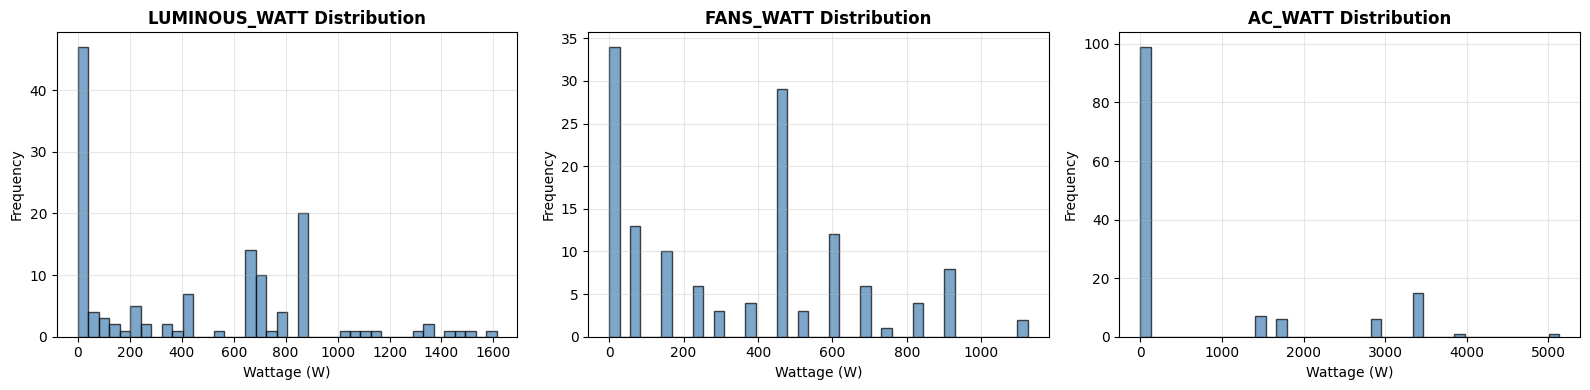

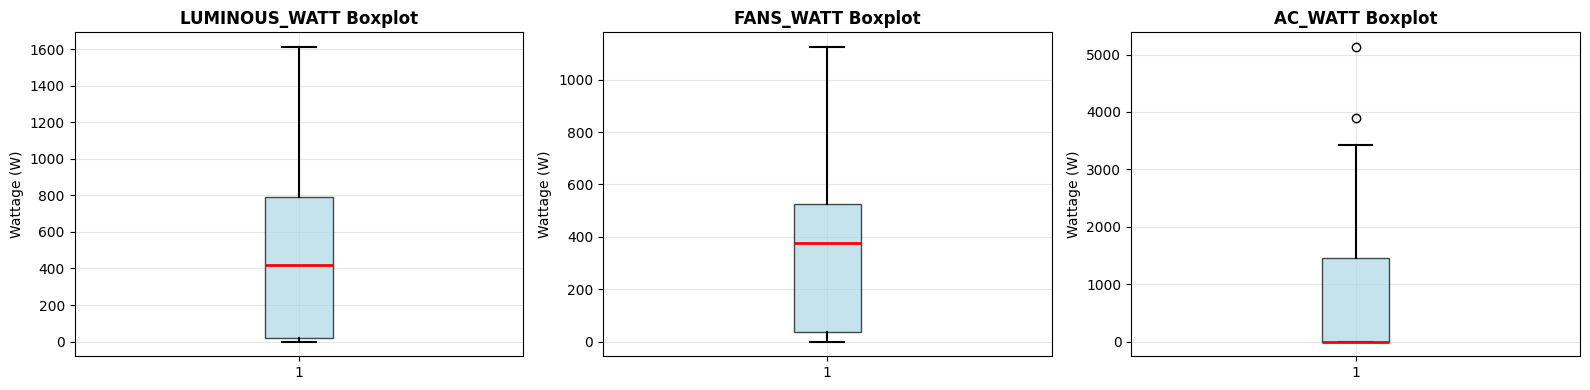

In [174]:

# 2. DISTRIBUTIONS: Energy Consumption by Category
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(energy_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Wattage (W)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(energy_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    axes[i].set_title(f'{col} Boxplot', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Wattage (W)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [175]:

# 3. ENERGY BREAKDOWN & INSIGHTS
print("\n" + "="*70)
print("2. ENERGY CONSUMPTION BREAKDOWN")
print("="*70)

# Create total energy column
df['TOTAL_ENERGY'] = df['LUMINOUS_WATT'] + df['FANS_WATT'] + df['AC_WATT']

# Energy breakdown
breakdown = {
    'Lighting (LUMINOUS_WATT)': df['LUMINOUS_WATT'].sum(),
    'Fans (FANS_WATT)': df['FANS_WATT'].sum(),
    'AC (AC_WATT)': df['AC_WATT'].sum(),
}

print("\nTotal Energy Consumption Distribution:")
for category, value in breakdown.items():
    pct = (value / df['TOTAL_ENERGY'].sum()) * 100
    print(f"  {category:30} : {value:12,.0f}W ({pct:5.1f}%)")

print(f"\n  {'TOTAL':30} : {df['TOTAL_ENERGY'].sum():12,.0f}W (100.0%)")

# Room-wise energy consumption
print("\n\nTOP 10 ROOMS by Energy Consumption:")
room_energy = df.groupby('ROOM')[['LUMINOUS_WATT', 'FANS_WATT', 'AC_WATT', 'TOTAL_ENERGY']].sum().sort_values('TOTAL_ENERGY', ascending=False).head(10)
print(room_energy.round(0))



2. ENERGY CONSUMPTION BREAKDOWN

Total Energy Consumption Distribution:
  Lighting (LUMINOUS_WATT)       :       59,752W ( 29.4%)
  Fans (FANS_WATT)               :       45,600W ( 22.4%)
  AC (AC_WATT)                   :       98,086W ( 48.2%)

  TOTAL                          :      203,438W (100.0%)


TOP 10 ROOMS by Energy Consumption:
      LUMINOUS_WATT  FANS_WATT  AC_WATT  TOTAL_ENERGY
ROOM                                                 
317           864.0      600.0   5130.0        6594.0
306          1152.0      825.0   3414.0        5391.0
303           864.0      900.0   3414.0        5178.0
304           864.0      900.0   3414.0        5178.0
314           864.0      900.0   3414.0        5178.0
305           864.0      900.0   3414.0        5178.0
310           864.0      900.0   3414.0        5178.0
311           792.0      825.0   3414.0        5031.0
313           792.0      825.0   3414.0        5031.0
131           864.0      375.0   3420.0        4659.0


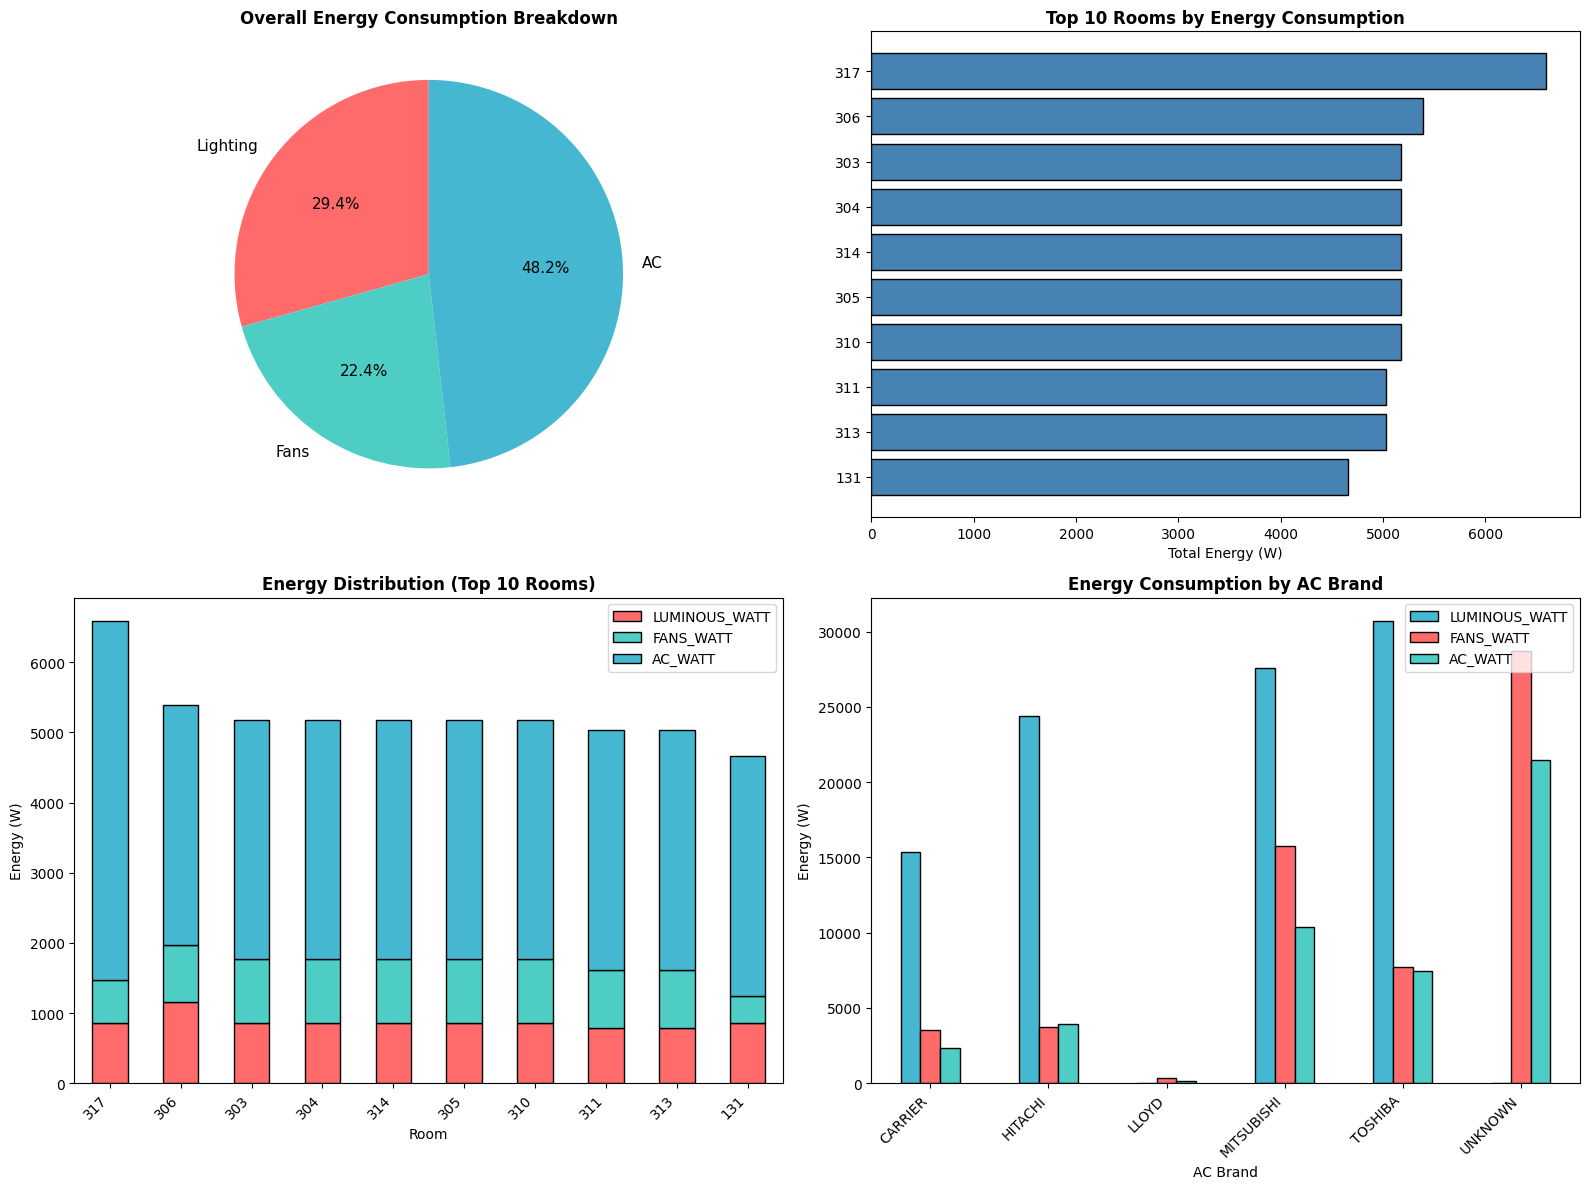

In [176]:

# 4. VISUALIZATIONS: Energy Breakdown
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Pie chart - Energy breakdown
breakdown_pct = [df['LUMINOUS_WATT'].sum(), df['FANS_WATT'].sum(), df['AC_WATT'].sum()]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0, 0].pie(breakdown_pct, labels=['Lighting', 'Fans', 'AC'], autopct='%1.1f%%', 
               colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0, 0].set_title('Overall Energy Consumption Breakdown', fontsize=12, fontweight='bold')

# Bar chart - Top 10 rooms
top_rooms = df.groupby('ROOM')['TOTAL_ENERGY'].sum().sort_values(ascending=False).head(10)
axes[0, 1].barh(top_rooms.index.astype(str), top_rooms.values, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Total Energy (W)')
axes[0, 1].set_title('Top 10 Rooms by Energy Consumption', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()

# Stacked bar - Category wise by top rooms
top_10_rooms_df = df[df['ROOM'].isin(top_rooms.index)].groupby('ROOM')[energy_cols].sum()
# Reorder by top_rooms order
top_10_rooms_df = top_10_rooms_df.loc[top_rooms.index]
top_10_rooms_df[energy_cols].plot(kind='bar', stacked=True, ax=axes[1, 0], 
                                  color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[1, 0].set_title('Energy Distribution (Top 10 Rooms)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Room')
axes[1, 0].set_ylabel('Energy (W)')
axes[1, 0].legend(energy_cols, loc='upper right')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# AC brand analysis
ac_brand_energy = df.groupby('AC COMPANY CLEANED')[['AC_WATT', 'LUMINOUS_WATT', 'FANS_WATT']].sum()
ac_brand_energy.plot(kind='bar', ax=axes[1, 1], color=['#45B7D1', '#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 1].set_title('Energy Consumption by AC Brand', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('AC Brand')
axes[1, 1].set_ylabel('Energy (W)')
axes[1, 1].legend(energy_cols, loc='upper right')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



3. CORRELATION ANALYSIS


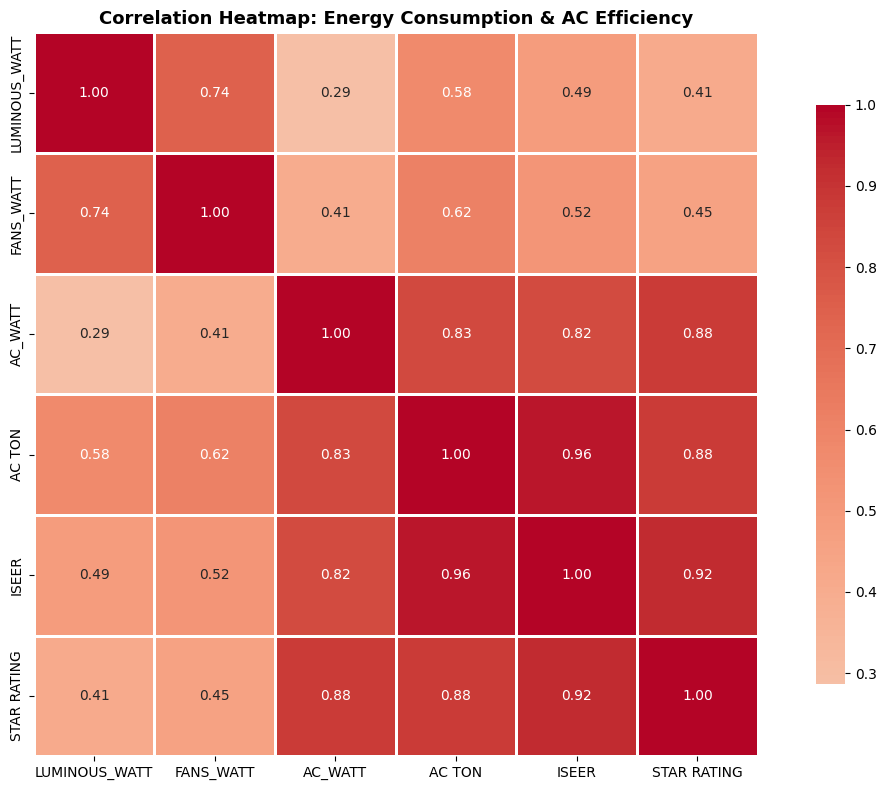

In [177]:

# 5. CORRELATION ANALYSIS
print("\n" + "="*70)
print("3. CORRELATION ANALYSIS")
print("="*70)

# Correlation matrix for numeric columns
numeric_cols_df = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols_df].corr()

# Heatmap - just use numeric columns
plt.figure(figsize=(12, 8))
top_corr_cols = energy_cols + ['AC TON', 'ISEER', 'STAR RATING']
top_corr_cols = [col for col in top_corr_cols if col in corr_matrix.columns]
if len(top_corr_cols) > 0:
    corr_subset = corr_matrix.loc[top_corr_cols, top_corr_cols]
    sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap: Energy Consumption & AC Efficiency', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [178]:

# 6. AC EFFICIENCY INSIGHTS
print("\n" + "="*70)
print("4. AC EFFICIENCY & BRAND ANALYSIS")
print("="*70)

# Filter rows with AC units (convert AC column to numeric first)
df['AC_numeric'] = pd.to_numeric(df['AC'], errors='coerce').fillna(0)
ac_data = df[df['AC_numeric'] > 0].copy()

print(f"\nTotal rooms with AC units: {ac_data['ROOM'].nunique()}")
print(f"Total AC units installed: {ac_data['AC_numeric'].sum():.0f}")

print("\n\nAC BRAND PERFORMANCE (Rooms with AC):")
ac_brand_stats = ac_data.groupby('AC COMPANY CLEANED').agg({
    'AC_numeric': 'sum',
    'STAR RATING': 'mean',
    'ISEER': 'mean',
    'AC_WATT': 'mean',
    'AC TON': 'mean'
}).round(2)
ac_brand_stats.columns = ['Avg ACs', 'Avg Star Rating', 'Avg ISEER', 'Avg Power (W)', 'Avg Capacity (TON)']
ac_brand_stats = ac_brand_stats.sort_values('Avg ISEER', ascending=False)
print(ac_brand_stats)

print("\n\nINSIGHT: ISEER (Indian Seasonal Energy Efficiency Ratio)")
print("- Higher ISEER = Better efficiency (Less power for same cooling)")
print("- AC brand efficiency ranking (by ISEER):")
for brand, row in ac_brand_stats.iterrows():
    print(f"  {brand:15} : ISEER = {row['Avg ISEER']:5.2f} | Star Rating = {row['Avg Star Rating']:4.1f}")



4. AC EFFICIENCY & BRAND ANALYSIS

Total rooms with AC units: 76
Total AC units installed: 126


AC BRAND PERFORMANCE (Rooms with AC):
                    Avg ACs  Avg Star Rating  Avg ISEER  Avg Power (W)  \
AC COMPANY CLEANED                                                       
TOSHIBA                18.0              3.0       3.75        3414.00   
CARRIER                11.0              5.0       3.72        3078.00   
HITACHI                22.0              3.0       3.60        1526.25   
MITSUBISHI             23.0              2.0       3.53        1721.88   
UNKNOWN                51.0              NaN       1.00           0.00   
LLOYD                   1.0              NaN        NaN           0.00   

                    Avg Capacity (TON)  
AC COMPANY CLEANED                      
TOSHIBA                           2.00  
CARRIER                           1.84  
HITACHI                           1.40  
MITSUBISHI                        1.86  
UNKNOWN                  

In [179]:
# 7. KEY FINDINGS & ACTIONABLE INSIGHTS
print("\n" + "="*70)
print("5. KEY FINDINGS & ACTIONABLE INSIGHTS")
print("="*70)

print("\n ENERGY CONSUMPTION INSIGHTS:")
print("-" * 70)

# Finding 1: Energy breakdown
total_energy = df['TOTAL_ENERGY'].sum()
lighting_pct = (df['LUMINOUS_WATT'].sum() / total_energy) * 100
fans_pct = (df['FANS_WATT'].sum() / total_energy) * 100
ac_pct = (df['AC_WATT'].sum() / total_energy) * 100

print(f"\n1️ Energy Distribution:")
print(f"   • Lighting consumes: {lighting_pct:.1f}% of total energy")
print(f"   • Fans consume:      {fans_pct:.1f}% of total energy")
print(f"   • AC consumes:       {ac_pct:.1f}% of total energy")

# Finding 2: High consumption rooms
print(f"\n2️ Heavy Energy Consumers:")
top_3 = df.groupby('ROOM')['TOTAL_ENERGY'].sum().nlargest(3)
for i, (room, energy) in enumerate(top_3.items(), 1):
    pct = (energy / total_energy) * 100
    print(f"   • Room {room}: {energy:,.0f}W ({pct:.2f}% of total)")

# Finding 3: AC efficiency
print(f"\n3️ AC Units & Efficiency:")
rooms_with_ac = (df['AC_numeric'] > 0).sum()
avg_iseer = ac_data['ISEER'].mean()
print(f"   • Rooms with AC: {rooms_with_ac} ({(rooms_with_ac/len(df))*100:.1f}%)")
print(f"   • Average ISEER: {avg_iseer:.2f} (Target: >3.0 for 5-star efficiency)")

# Finding 4: Star ratings
star_dist = df['STAR RATING'].value_counts().sort_index(ascending=False)
print(f"\n4️  AC Star Rating Distribution:")
for stars, count in star_dist.items():
    if pd.notna(stars):
        ac_total = df['AC_numeric'].sum()
        if ac_total > 0:
            print(f"   • {int(stars)} : {int(count)} units ({(count/ac_total)*100:.1f}% of ACs)")

# Finding 5: Lighting opportunities
lighting_rooms = df[df['LUMINOUS_WATT'] > 0].groupby('ROOM')['LUMINOUS_WATT'].sum().nlargest(5)
print(f"\n5 Top Lighting Energy Consumers (Optimization Opportunities):")
for room, watt in lighting_rooms.items():
    print(f"   • Room {room}: {watt:,.0f}W")

print("\n" + "="*70)
print("RECOMMENDATIONS:")
print("="*70)
print("""
1. LIGHTING OPTIMIZATION:
   ✓ Install LED-TB fixtures (lower wattage alternatives)
   ✓ Implement motion sensors in low-occupancy rooms
   ✓ Consider dimmable lighting systems

2. AC EFFICIENCY:
   ✓ Prioritize upgrading low-efficiency ACs (<3 ISEER)
   ✓ Focus on TOSHIBA/CARRIER brands (higher ISEER: 3.7+)
   ✓ Maintain regular AC servicing for optimal performance

3. FAN MANAGEMENT:
   ✓ Install variable-speed fan controllers
   ✓ Replace exhaust fans with energy-efficient models
   ✓ Use fans strategically to reduce AC load

4. ROOM-LEVEL FOCUS:
   ✓ Conduct detailed audits in top 10 energy-consuming rooms
   ✓ Identify wasteful usage patterns
   ✓ Implement targeted conservation measures
""")
print("="*70)



5. KEY FINDINGS & ACTIONABLE INSIGHTS

 ENERGY CONSUMPTION INSIGHTS:
----------------------------------------------------------------------

1️ Energy Distribution:
   • Lighting consumes: 29.4% of total energy
   • Fans consume:      22.4% of total energy
   • AC consumes:       48.2% of total energy

2️ Heavy Energy Consumers:
   • Room 317: 6,594W (3.24% of total)
   • Room 306: 5,391W (2.65% of total)
   • Room 303: 5,178W (2.55% of total)

3️ AC Units & Efficiency:
   • Rooms with AC: 76 (56.3%)
   • Average ISEER: 3.49 (Target: >3.0 for 5-star efficiency)

4️  AC Star Rating Distribution:
   • 5 : 4 units (3.2% of ACs)
   • 3 : 19 units (15.1% of ACs)
   • 2 : 18 units (14.3% of ACs)
   • 0 : 42 units (33.3% of ACs)

5 Top Lighting Energy Consumers (Optimization Opportunities):
   • Room 218: 1,612W
   • Room 129: 1,496W
   • Room 128: 1,456W
   • Room AUDITORIUM: 1,440W
   • Room 324-b: 1,368W

RECOMMENDATIONS:

1. LIGHTING OPTIMIZATION:
   ✓ Install LED-TB fixtures (lower watt

# Exploratory Data Analysis (EDA)

In [181]:

# ── 1. Overview ──────────────────────────────────────────────
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
df.describe(include='all').T


Shape: (135, 51)

Data Types:
                       float64
ROOM                   object
2x2 LIGHT             float64
WATT                  float64
LED-TB                float64
WATT.1                float64
SENSOR LIGHT          float64
WATT.2                float64
ROUND TB               object
WATT.3                float64
FLOODE                float64
WATT.4                float64
CIRCLE LIGHT          float64
WATT.5                float64
C FAN                 float64
WATT.6                float64
WALL FAN              float64
WATT.7                float64
TABLE FAN             float64
WATT.8                float64
EXHAUST FAN           float64
WATT.9                float64
COOLER                float64
WATT.10               float64
AC                     object
STAR RATING           float64
WATT.11                object
AC TON                float64
ISEER                 float64
PROJECTOR             float64
WATT.12               float64
PC                     object
WATT.13  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROOM,133,132,Passage,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2x2 LIGHT,121.0,NaN,NaN,NaN,6.082645,5.968789,0.0,0.0,6.0,11.0,21.0
WATT,133.0,NaN,NaN,NaN,36.0,0.0,36.0,36.0,36.0,36.0,36.0
LED-TB,121.0,NaN,NaN,NaN,1.760331,4.893916,0.0,0.0,0.0,2.0,42.0
WATT.1,133.0,NaN,NaN,NaN,20.0,0.0,20.0,20.0,20.0,20.0,20.0
SENSOR LIGHT,123.0,NaN,NaN,NaN,0.186992,2.07384,0.0,0.0,0.0,0.0,23.0
WATT.2,133.0,NaN,NaN,NaN,20.0,0.0,20.0,20.0,20.0,20.0,20.0
ROUND TB,121,9,0,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WATT.3,133.0,NaN,NaN,NaN,39.699248,3.46844,0.0,40.0,40.0,40.0,40.0


In [182]:
df.head()

,,ROOM,2x2 LIGHT,WATT,LED-TB,WATT.1,SENSOR LIGHT,WATT.2,ROUND TB,WATT.3,...,TV,WATT.18,Unnamed: 45,Others,AC COMPANY CLEANED,LUMINOUS_WATT,FANS_WATT,AC_WATT,TOTAL_ENERGY,AC_numeric
0,NaN,101,0.0,36.0,2.0,20.0,0.0,20.0,2,40.0,...,0.0,NaN,NaN,NaN,MITSUBISHI,120.0,75.0,1450.0,1645.0,1.0
1,NaN,102,5.0,36.0,3.0,20.0,0.0,20.0,0,40.0,...,0.0,NaN,NaN,NaN,HITACHI,420.0,300.0,1710.0,2430.0,1.0
2,NaN,106,10.0,36.0,0.0,20.0,0.0,20.0,0,40.0,...,0.0,NaN,NaN,NaN,MITSUBISHI,720.0,450.0,2900.0,4070.0,2.0
3,NaN,107,0.0,36.0,0.0,20.0,0.0,20.0,0,40.0,...,0.0,NaN,NaN,NaN,UNKNOWN,0.0,675.0,0.0,675.0,2.0
4,NaN,108,9.0,36.0,4.0,20.0,0.0,20.0,0,40.0,...,0.0,NaN,NaN,NaN,MITSUBISHI,728.0,675.0,1450.0,2853.0,1.0


In [ ]:
df.drop(df.columns[10:14], axis=1, inplace=True)
df.drop(df.columns[12:20], axis=1, inplace=True)
df.drop(df.columns[17:33], axis=1, inplace=True)
df.drop(columns=[df.columns[0], 'SENSOR LIGHT','WATT.2'], inplace=True)


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Hitarth Khatiwala\\HEMS\\hems_backend\\EE_EC_AIML_CLEANED.csv'

In [184]:
df.head()

,ROOM,2x2 LIGHT,WATT,LED-TB,WATT.1,ROUND TB,WATT.3,C FAN,WATT.6,AC,STAR RATING,WATT.11,AC TON,ISEER,AC COMPANY CLEANED,LUMINOUS_WATT,FANS_WATT,AC_WATT,TOTAL_ENERGY,AC_numeric
0,101,0.0,36.0,2.0,20.0,2,40.0,1.0,75.0,1,2.0,1450,2.0,3.53,MITSUBISHI,120.0,75.0,1450.0,1645.0,1.0
1,102,5.0,36.0,3.0,20.0,0,40.0,4.0,75.0,1,3.0,1710,1.0,3.60,HITACHI,420.0,300.0,1710.0,2430.0,1.0
2,106,10.0,36.0,0.0,20.0,0,40.0,6.0,75.0,2,2.0,1450,2.0,3.53,MITSUBISHI,720.0,450.0,2900.0,4070.0,2.0
3,107,0.0,36.0,0.0,20.0,0,40.0,9.0,75.0,2,NaN,NaN,NaN,NaN,UNKNOWN,0.0,675.0,0.0,675.0,2.0
4,108,9.0,36.0,4.0,20.0,0,40.0,9.0,75.0,1,2.0,1450,2.0,3.53,MITSUBISHI,728.0,675.0,1450.0,2853.0,1.0


In [ ]:

# Save processed data to CSV
output_path = 'C:\\Users\\Hitarth Khatiwala\\HEMS\\hems_backend\\EE_EC_AIML_PROCESSED.csv'
df.to_csv(output_path, index=False)

print("✅ Data saved successfully!")
print(f"\nOutput file: {output_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"\nNew calculated columns added:")
print("  • LUMINOUS_WATT: Lighting energy consumption")
print("  • FANS_WATT: Fans energy consumption")
print("  • AC_WATT: AC units energy consumption")
print("  • TOTAL_ENERGY: Total energy (sum of above)")
print("  • AC_numeric: AC units count (numeric)")

print(f"\nFirst few rows of processed data:")
print(df[['ROOM', 'LUMINOUS_WATT', 'FANS_WATT', 'AC_WATT', 'TOTAL_ENERGY', 'AC COMPANY CLEANED']].head(10))


✅ Data saved successfully!

Output file: C:\Users\Hitarth Khatiwala\HEMS\hems_backend\EE_EC_AIML_PROCESSED.csv
Rows: 135
Columns: 20

New calculated columns added:
  • LUMINOUS_WATT: Lighting energy consumption
  • FANS_WATT: Fans energy consumption
  • AC_WATT: AC units energy consumption
  • TOTAL_ENERGY: Total energy (sum of above)
  • AC_numeric: AC units count (numeric)

First few rows of processed data:
  ROOM  LUMINOUS_WATT  FANS_WATT  AC_WATT  TOTAL_ENERGY AC COMPANY CLEANED
0  101          120.0       75.0   1450.0        1645.0         MITSUBISHI
1  102          420.0      300.0   1710.0        2430.0            HITACHI
2  106          720.0      450.0   2900.0        4070.0         MITSUBISHI
3  107            0.0      675.0      0.0         675.0            UNKNOWN
4  108          728.0      675.0   1450.0        2853.0         MITSUBISHI
5  109          788.0      675.0   1450.0        2913.0         MITSUBISHI
6  110          400.0      225.0   3420.0        4045.0       